# Industrial defect intelligence: reproducible fresh experiment

**Research question:** To what extent does end-to-end representation learning improve six-class steel-surface defect classification over handcrafted HOG features, when validation, image conditions and practical computational costs are controlled?

This notebook is the complete implementation. Run it from an otherwise empty project folder or the project root, using a fresh kernel and **Run All**. It acquires raw data if absent and creates a new timestamped output directory on every execution. No previous notebook, manifest, checkpoint, report or experiment output is required. All training executes by default. Allow time for both five-fold CNN experiments on CPU.

Install into the notebook's Python environment before running:

```bash
python -m pip install numpy pandas matplotlib pillow scikit-learn scikit-image joblib torch==2.14.0 torchvision==0.29.0 captum==0.9.0 tqdm scipy ipython ipykernel nbformat nbclient jupyterlab
```

Torchvision is included for the specified environment, although this custom CNN does not use pretrained models. SciPy supplies the explicitly defined image-condition operators. The remaining Jupyter packages support execution and display. Exact installed versions and machine details are saved by the run.

The task assigns an already selected defect image to one of six classes. **There is no normal or defect-free class.** This experiment cannot measure defect-versus-normal detection, production false-alarm rates or localisation accuracy. The notebook generates numerical evidence; its prose explains methods rather than interpreting run-dependent results.

## 1. Experimental controls and predeclared analysis

Pool the source containers, audit image integrity, exclude exact duplicate content deterministically, and create an image-level stratified 80/20 development/test split with seed 42. Create shared five-fold stratified validation assignments within development. The source folder names do not define this experiment's partitions. No bounding-box annotation is a classifier input.

The baseline uses fixed native-resolution HOG [3] and six SVM [4] candidates: linear and RBF kernels, each with C in {0.1, 1, 10}; RBF gamma is `scale`. Fit StandardScaler inside each training fold. Select the highest mean fold macro F1, with candidate order resolving exact ties. HOG parameters are fixed rather than searched.

The custom CNN uses three convolution, batch normalisation, ReLU and pooling blocks, global average pooling and dropout. CPU execution, one seeded initialisation per fold, AdamW, cross-entropy and no augmentation give a bounded comparison. Checkpoint selection uses strictly improving validation macro F1, earliest exact tie, patience five and an initial cap of 25 epochs. Validation loss is diagnostic only.

**Single controlled epoch-cap sensitivity:** rerun all five folds from the same seeds with cap 40, changing no other setting. Adopt 40 only if at least two folds improve by at least 0.005 macro F1, each originally stopped solely at the 25 ceiling, and each selects an epoch beyond 25. Retain 25 as adequate under this check if absolute mean change is at most 0.002, no fold improves by at least 0.005, and at least three extended folds stop by patience before 40. Otherwise retain 25 provisionally with inconclusive adequacy. Failure of common-prefix agreement within 1e-10 prevents automatic adoption. These are pragmatic thresholds, not significance levels. No further tuning follows. Refit for the ceiling of the median selected epoch under the chosen cap.

Before unlocking the test images, freeze both fitted models, normalisation, subgroup cut points and stress-test severities. Evaluate each clean test image once per model for the primary comparison. Later diagnostics reuse those predictions; perturbations and timing are explicitly separate evaluations of frozen models.

Accuracy measures overall correctness. Macro precision, recall and F1 weight the six classes equally; F1 is averaged across classwise F1 values. Undefined class precision is set to zero. Report class support and confusion counts. Selection CV is not nested CV: reused validation folds and checkpoint selection introduce optimism, and fold SD is descriptive rather than a confidence interval. Equal folds do not equalise model search budgets. No formal significance claim is made.

In [1]:
# VERIFICATION DEMO: reads saved artefacts only. No training or fresh model inference.
# The unchanged markdown describes the original complete experiment.
from pathlib import Path
from time import perf_counter
import hashlib
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from IPython.display import display, Image, Markdown

START = perf_counter()
ROOT = Path(r'C:\Scripts\industrial-defect-intelligence')
RUN = ROOT / 'outputs' / 'fresh_20260927T194627_610401Z'
SHOW_LARGE_EXPLANATION_FIGURE = False
PINNED_SHA256 = {'status.json': '7046b4c37582dd9944e7f15571f4fbcba19307d480b3ae257950e75c1d7d4b96', 'result.json': '3ec17096cb879399d895b297a667b1faefb6b48ea10272efabca318fe878de4e', 'freeze.json': '184eed00b581fe6b4923a4f720166dc94a4bd06de116802cd94c7b8b7cefeee5', 'protocol.json': '7846f4cb7c84b7d0197ae68c7248e5da251eb7e0845f390e68766d16fcb9fa7e', 'environment.json': 'e45288d1af422b274cd370365e594b8c8c6dedc7aa3841f82e7234a1089fb387', 'acquisition.json': 'fe6c6e65239f2a3044b58e743427242fb7c3d43aa439517a059bc9b2fe5c4ce7', 'raw_audit_summary.csv': 'fb0ce9f23697f92cea62f1fba6e8110900c7c82194231be54238d71cd5e8d465', 'duplicate_decisions.csv': 'b9522b40d49bf836a44bbe5e87a2db65a866639f30526de567aa451863006ace', 'manifest.csv': '36dd971dd2e60a1ad91fad76524551c81500eece82b7fc68b32c5b48577530f4', 'shared_folds.csv': '2fc05ad80840bf956bec63339a755b5a4afdb2fdffa970c084374cbda5791b84', 'split_counts.csv': '846517ee520a8217691507e4a4434d688468418671b30e6d8acd79fe37bf46e3', 'fold_counts.csv': '29841b1c7c46a4a973ed2e46a0799eeeb6539da164d272218bbb137b23b1f0de', 'development_condition_summary.csv': 'bc156cf88798b9fe5b083865f8619b370787ccfa97a40b8249cdf5e636a9282c', 'development_examples.png': '89410fcff4beb257c1f21b4a3c5b0fdbb12db7420167662a7177b744c3046a00', 'svm_candidate_folds.csv': '48c08a921f66f4a9189fd3d063a3ceb1470d85841c3424440285421b70f394b4', 'svm_selection.csv': '1db4ab4d942c572064bc07a458761abeef81dd96d2a9550d4e35de84a2f502a5', 'cnn25_folds.csv': '759f23aeaec7223c0ac041e3d3184a6b817babebdbef751f7f2b688df27d6487', 'cnn40_folds.csv': '3f36ae7fff7fc2f7f7772f77174651279e5524ed93bb26bc0c48c6cdcda5a0f9', 'epoch_cap_comparison.csv': 'fa0f89fcee7964f044e4f686e4bc92be56e05c2f4ba280d9dbf2c89d8fd5d2f8', 'sensitivity_decision.json': '4b9776a6c7e4c9dad8a166b2c19724d0e2127393d85ec180eaad711f75d59b27', 'epoch_cap_sensitivity.png': '368ae519d523d29835ddeb372b5dc0b7f3ec945bfe6ae9fa049caa403ef171e8', 'selected_cnn_learning_curves.png': 'd80b217c993e20ec0721639b85f48261e9c1d4caec841c5b2035de074692cbaa', 'development_comparison.csv': 'f6ce71cf86624da69f802f56442e1cc5980dd966f1aa4a2ea13d8419ab8472f7', 'cnn_final_training_history.csv': '8606a38f29cf099a3d8a898d7049a8430465d5d131ef400aabad6e048c595f7d', 'final_svm.joblib': 'cbedd4f8babcd2cb11b8ddc2a13685dff3b5b837019a98dab3dec847ab15a003', 'final_cnn.pt': '3b3939567d73e6867b4a6183e6a80b1e5db76177794f2a548ca6f09416daac03', 'test_predictions.csv': '891789b03360583c4733acec440e0fcf590c2cd6bbcbf94e536a2a1a0dc3f8fa', 'test_results.csv': 'ccb816b3422e2471476485ef232100907152018bcb257a9a27847eda71957510', 'HOG-SVM_per_class.csv': 'a5c04e5378fc240e2fa21c376047c0d60e3715ed471b145609a1ed9cc2b0362f', 'CNN_per_class.csv': 'a569cb6118e30207ed2d1ecf5d116eb675f587c27479e6e03d838c311cbb9469', 'HOG-SVM_confusion_counts.csv': '372c7ad5e007724e7132a5533b42fddd8dd4e5933ecc4ba31c4ca40eb8ccd9dd', 'CNN_confusion_counts.csv': 'e9942343e28c57c24b6140405fa1b9dc5b4adff1a6fc2fdf09d8108ac31d8fbf', 'HOG-SVM_confusion.png': 'bda2d485fe79f5057213cb0f567232da4f2d712044fff25ea8575eb200d56c40', 'CNN_confusion.png': 'cb21d2282ab5863e21db82128c861be311ed0ab747548c72c7f73994063baeaf', 'paired_correctness.csv': '8f898d4550baa417975a73e95315c33dafb2652bd4158f8a5b8f389d077c0034', 'directed_errors.csv': '9136c5006876e2f19e66f98e01e065aa6f943170755494e06d6bb8d2ab7a5f4d', 'error_examples.png': 'b2ae198f79f9a21e0bc9cfea2ef718c59e54c0516acfbc64662dd805400948ca', 'gradcam_registry.csv': 'fd98245752e35d86b5e3dd43eadc8701f5df454829b786f59bba2dab64309d0a', 'explanations.png': '3654b4dfbfca941e8c49294cc33cbfc28146c78b8cc3657c067279cac5439478', 'subgroup_composition.csv': '1a91da50058dcc96c970f3730194d484ddfb3ed842398ce82a86877756712d38', 'subgroup_metrics.csv': 'a1a566ad2e655f8ff962cba08b088cc298e808011800ac6ba4fc44845187c5b4', 'robustness.csv': 'c42150b02a9958c004e901fccb1d56119fd4d2310d14583125bcc1864be8fd39', 'robustness_comparison.png': 'b0fc71d653dd74d3d6df99155808f75e02a6351780879c32a20a45c93549ada0', 'latency.csv': 'c3e6e81e980de2bd68ba0a4cdeecb0150520bf47fce0b421550164fed1dd930b', 'throughput.csv': '89a8706924bd4bf959c6eb5c88fadf0a990dca35f3a82819a30bee35d2d54cfa', 'efficiency.csv': '5a42b1afe30ae9dc9827b91a4c7c216c63c00e878a613df0d459bbbb19945f45', 'timing_scope.json': '9f60ddb7de048d4e55c6639607008a1b8cf58d94b371427c9d7ea90e1be95c9c', 'acceptance_checks.csv': '651f34078756a3a7e82ffb10048d847a5953a569b7171eb385269a74d2b8816d', 'predictions_blur.csv': 'bd99aaee78731a1c86c20af0c9f4bac8612e9d199ca2a7827017e2a7858be1be', 'predictions_brightness_low.csv': 'ff4f7725a778dfc06878c78b6704748c27ccecb3a43fb6245b41e77bda02aebd', 'predictions_brightness_high.csv': '73241d28271e67b4a4086d76ffeb0d040004b9fcc2b562120fc5b68c5537c5e0', 'predictions_contrast.csv': '21f069b1630d0ec8d4730eef9aae1313562e0115ea308ddff764020c88ba68b1', 'predictions_noise.csv': 'bca8a8eb18b75da6e9119f6675e8b15528ed75f1ff4becaf9395445839c4bf1f'}
checks=[]
def check(name, passed):
    checks.append({'check':name,'result':'PASS' if bool(passed) else 'FAIL'})
    if not passed:
        raise RuntimeError('Verification failed: '+name+'. Do not replace evidence or retrain to bypass this check.')
def sha(path):
    with path.open('rb') as handle:
        return hashlib.file_digest(handle,'sha256').hexdigest()
def read_json(name): return json.loads((RUN/name).read_text(encoding='utf-8'))
def read_table(name, **kwargs): return pd.read_csv(RUN/name, **kwargs)
def show_table(name):
    frame=read_table(name)
    display(frame)
    return frame
def show_figure(name, width=1000):
    display(Image(filename=str(RUN/name),width=width))
def metrics(truth,pred):
    p,r,f,_=precision_recall_fscore_support(truth,pred,labels=CLASSES,average='macro',zero_division=0)
    return dict(accuracy=accuracy_score(truth,pred),precision_macro=p,recall_macro=r,f1_macro=f)

display(Markdown('**Saved experiment verification demo.** Training was completed beforehand. This copy checks saved files, recomputes metrics from saved predictions and displays original figures. It does not train, load model objects, generate predictions, download data or write experiment files. The original markdown is retained unchanged and describes the full experiment, not the actions performed by this demonstration.'))
check('Fixed original experiment exists',RUN.is_dir())
for name, expected in PINNED_SHA256.items():
    check('Evidence checksum: '+name,(RUN/name).is_file() and sha(RUN/name)==expected)
status=read_json('status.json'); result=read_json('result.json'); frozen=read_json('freeze.json')
check('Original experiment completed successfully',status['status']==result['status']=='PASS')
check('Original recorded acceptance checks passed',all(v is True for v in result['checks'].values()))
protocol=read_json('protocol.json'); CLASSES=protocol['classes']
for name,key in [('final_svm.joblib','svm_sha256'),('final_cnn.pt','cnn_sha256'),('manifest.csv','split_sha256'),('shared_folds.csv','fold_sha256'),('protocol.json','protocol_sha256')]:
    check('Matches original freeze: '+name,sha(RUN/name)==frozen[key])
print('Verified original run:',RUN.name)
print('Model files verified by checksum only; neither model has been loaded or run.')
print('Additional evidence checksums were pinned when this demo was prepared; they detect later changes, not independent proof of historical provenance.')
display(pd.DataFrame(read_json('environment.json')['packages'].items(),columns=['Original package','Recorded version']))

**Saved experiment verification demo.** Training was completed beforehand. This copy checks saved files, recomputes metrics from saved predictions and displays original figures. It does not train, load model objects, generate predictions, download data or write experiment files. The original markdown is retained unchanged and describes the full experiment, not the actions performed by this demonstration.

Verified original run: fresh_20260927T194627_610401Z
Model files verified by checksum only; neither model has been loaded or run.
Additional evidence checksums were pinned when this demo was prepared; they detect later changes, not independent proof of historical provenance.


,Original package,Recorded version
0,numpy,2.5.3
1,pandas,3.0.6
2,matplotlib,3.11.2
3,pillow,12.3.0
4,scikit-learn,1.9.1
5,scikit-image,0.26.0
6,joblib,1.6.0
7,torch,2.14.0
8,torchvision,0.29.0
9,captum,0.9.0


## 2. Raw-data acquisition and safe extraction

Use the established Figshare version-1 NEU-CLS distribution [1], attributed alongside the original NEU researchers [2]. The direct download and published MD5 are recorded below in the implementation. If raw images are absent, download into this run's directory, verify the published byte count and MD5, then extract to a new data directory. Reject traversal, absolute paths, links, duplicate destinations and excessive uncompressed size. A partial existing dataset fails the subsequent audit rather than being silently mixed with a download.

MD5 checks correspondence with the published distribution; it is not collision-resistant proof. The Figshare copy's equivalence to a separately hosted university archive and intervening repackaging history are not established. Figshare states CC BY 4.0 for its distribution: retain attribution, link the licence and identify transformations. Existing raw files are audited afresh; no local provenance report or saved manifest is read.

In [2]:
# Display the recorded acquisition information. No download or extraction.
show_table_data = pd.DataFrame([read_json('acquisition.json')])
display(show_table_data)
print('Saved acquisition record only. Raw images are not opened by this demo.')

,source,published_md5,published_size,mode
0,https://ndownloader.figshare.com/files/54094775,19af5a1250d8ab0cb0828d31ee2b349d,27316154,existing raw files; independent audit below


Saved acquisition record only. Raw images are not opened by this demo.


## 3. Fresh integrity audit and duplicate policy

Parse labels from the validated filename prefix and numeric suffix, not generic container names. Require the declared six-class scope, expected raw class balance, readable single-frame images, dimensions and greyscale content. RGB storage is acceptable only when all three channels agree exactly. Record byte SHA-256 and decoded greyscale pixel SHA-256. Reject conflicting labels within a pixel-identical group and retain its lexicographically first relative path. Raw files remain unchanged. Exact hashing does not detect near-duplicates or common acquisition groups.

The integrity audit necessarily decodes the entire raw collection before a test partition exists. It performs no model fitting or result-guided selection. After partition creation, an access guard blocks test-file reads until the freeze point. Earlier project exposure to this benchmark cannot be undone by a new execution: this is a fresh computational reproduction, not a prospectively unseen external study.

In [3]:
# Display saved audit evidence rather than opening the 1,800 images again.
show_table('raw_audit_summary.csv')
show_table('duplicate_decisions.csv')
manifest=read_table('manifest.csv')
check('Recorded manifest contains 1800 unique paths',len(manifest)==1800 and manifest.path.is_unique)
check('Recorded split sizes',manifest.split.value_counts().to_dict()=={'development':1439,'test':360,'excluded':1})

,class_name,mode,width,height,greyscale,size
0,crazing,RGB,200,200,True,300
1,inclusion,RGB,200,200,True,300
2,patches,RGB,200,200,True,300
3,pitted_surface,RGB,200,200,True,300
4,rolled-in_scale,RGB,200,200,True,300
5,scratches,RGB,200,200,True,300


,path,class_name,sha256,pixel_sha256,included,retained_path
0,data/NEU-CLS/train/train/images/patches_101.jpg,patches,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...,2674e119fd69aaa9f2a662e3965defd66351521f3f7cb5...,True,data/NEU-CLS/train/train/images/patches_101.jpg
1,data/NEU-CLS/train/train/images/patches_105.jpg,patches,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...,2674e119fd69aaa9f2a662e3965defd66351521f3f7cb5...,False,data/NEU-CLS/train/train/images/patches_101.jpg


## 4. Deterministic split, shared folds and access boundary

The expected split sizes are protocol acceptance checks, not hardcoded assignments. Recreate assignments from the sorted unique-file manifest and stratified random generators. Assert unique-content separation and exactly one validation assignment per development image. The manifest and checksums saved here belong only to this execution.

The read guard permits audited development images and this run's outputs. It rejects prior experiment-output reads and, between split and freeze, any other raw dataset file. The deliberate denial check below requests a test file and verifies that access is rejected before opening. Audit records are local execution evidence rather than a security claim about other processes.

In [4]:
# Verify the recorded split and folds; never recreate or alter assignments.
show_table('split_counts.csv')
show_table('fold_counts.csv')
folds=read_table('shared_folds.csv')
dev=manifest.loc[manifest.split.eq('development')]
test=manifest.loc[manifest.split.eq('test')].sort_values('path').reset_index(drop=True)
check('Five shared development folds',len(folds)==1439 and folds.path.is_unique and set(folds.path)==set(dev.path) and set(folds.fold)==set(range(5)))
check('No recorded content overlap',not set(dev.pixel_sha256)&set(test.pixel_sha256))
print('Verified saved assignments. No split generation or test image access.')

,class_name,development,excluded,test
0,crazing,240,0,60
1,inclusion,240,0,60
2,patches,239,1,60
3,pitted_surface,240,0,60
4,rolled-in_scale,240,0,60
5,scratches,240,0,60


,class_name,0,1,2,3,4
0,crazing,48,48,48,48,48
1,inclusion,48,48,48,48,48
2,patches,48,48,48,48,47
3,pitted_surface,48,48,48,48,48
4,rolled-in_scale,48,48,48,48,48
5,scratches,48,48,48,48,48


Verified saved assignments. No split generation or test image access.


## 5. Development-only visual checks and diagnostic definitions

Show the first image per class in sorted development order, avoiding discretionary example selection. Define brightness as mean intensity, contrast as population intensity standard deviation and sharpness as the variance of a reflected-boundary discrete Laplacian, all on greyscale values scaled to [0,1]. Development tertiles define fixed test subgroup boundaries; ties go into the lower interval. These are image-condition diagnostics, not demographic fairness measures or causal explanations. They may be confounded by defect class and acquisition conditions.

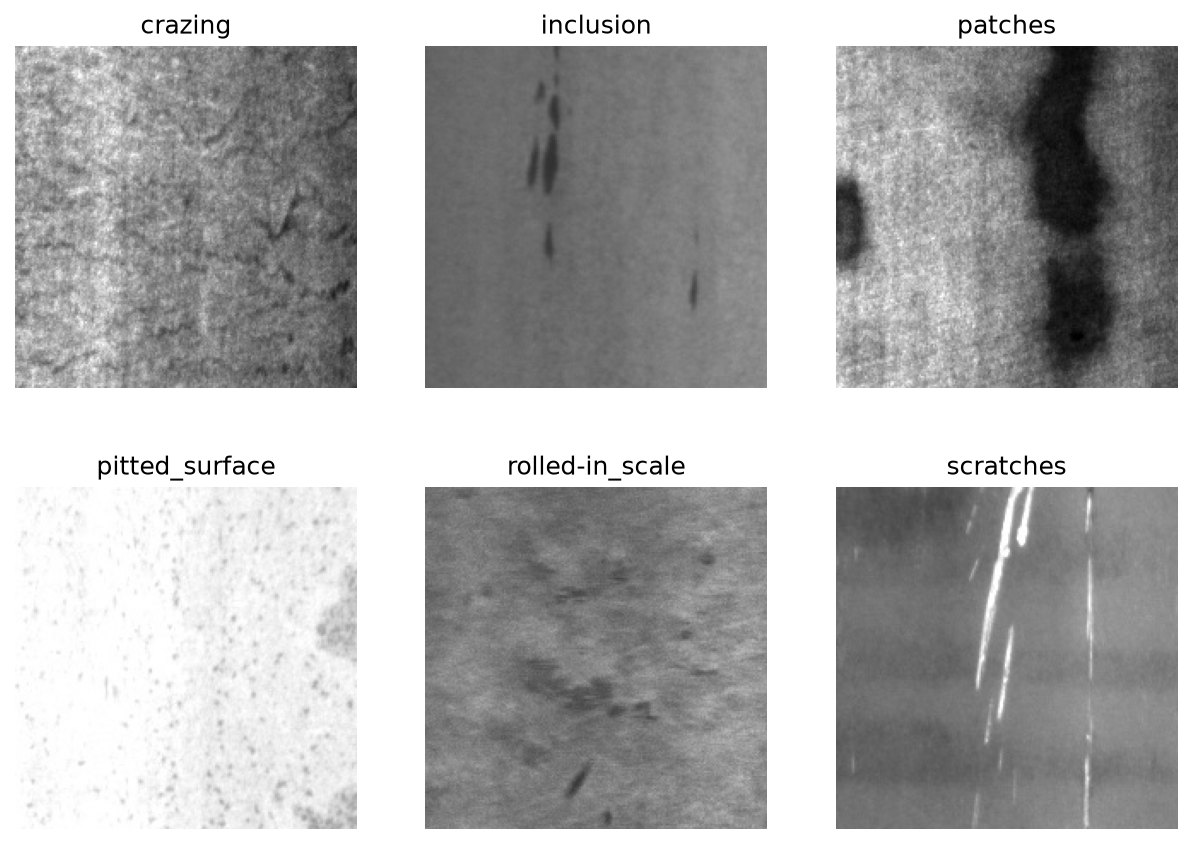

,index,brightness,contrast,sharpness
0,count,1439.000000,1439.000000,1439.000000
1,mean,0.503058,0.104993,0.011769
2,std,0.174861,0.060277,0.012631
3,min,0.136878,0.023419,0.000133
4,25%,0.364504,0.058531,0.001081
5,50%,0.492732,0.092551,0.006508
6,75%,0.612322,0.127410,0.021369
7,max,0.963323,0.288349,0.042525


,index,brightness,contrast,sharpness
0,count,1439.000000,1439.000000,1439.000000
1,mean,0.503058,0.104993,0.011769
2,std,0.174861,0.060277,0.012631
3,min,0.136878,0.023419,0.000133
4,25%,0.364504,0.058531,0.001081
5,50%,0.492732,0.092551,0.006508
6,75%,0.612322,0.127410,0.021369
7,max,0.963323,0.288349,0.042525


In [5]:
# Original development illustrations and recorded descriptive measurements.
show_figure('development_examples.png',850)
show_table('development_condition_summary.csv')

## 6. HOG-SVM development

HOG encodes local gradient orientations using nine bins, 16 by 16 pixel cells and 2 by 2 cell blocks with L2-Hys normalisation [3]. Incomplete border cells are omitted. Descriptor computation is independent of labels and does not fit statistics. Standardisation and SVM fitting occur inside each training fold [4]. Store every candidate score, select by mean fold macro F1 and retain selected out-of-fold predictions for descriptive development comparison.

In [6]:
# Saved SVM selection evidence. No feature extraction or fitting.
svm_folds=read_table('svm_candidate_folds.csv')
check('All 30 saved SVM fits present',len(svm_folds)==30 and not svm_folds.duplicated(['candidate','fold']).any() and svm_folds.groupby('candidate').size().eq(5).all())
show_table('svm_selection.csv')
print('Frozen SVM configuration:',frozen['svm'])

,candidate,mean_f1,sd_f1,fit_seconds
0,0,0.831926,0.011481,25.103482
1,1,0.831926,0.011481,9.036427
2,2,0.831926,0.011481,8.623221
3,3,0.709126,0.038219,35.278847
4,4,0.877231,0.011219,37.521219
5,5,0.887114,0.012463,54.307921


Frozen SVM configuration: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}


## 7. Compact CNN implementation and training procedure

Convert each greyscale image to one float channel at its native size. Estimate pixel mean and population standard deviation using only each fold's training images. Reuse those values for its validation images. The first convolution has stride two to bound CPU cost; subsequent pooling and global averaging reduce spatial detail. This architecture trades representational capacity and explanation resolution against compute. It is an independently trained custom model, with no transfer learning or augmentation.

The DataLoader uses a dedicated seeded generator and no workers. Deterministic CPU algorithms are requested, while cross-platform bitwise identity is not assumed. At each epoch, report both training and validation metrics in evaluation mode using the same weights; online optimisation loss is separate. Save every improving checkpoint and the full learning history. A patience stop describes this rule's local plateau, not global convergence.

In [7]:
# Show the original five-fold CNN results; no PyTorch model is instantiated.
cnn25=show_table('cnn25_folds.csv')
check('Five original CNN folds present',len(cnn25)==5 and set(cnn25.fold)==set(range(5)))
print('These are saved development results, not newly trained models.')

,cap,fold,best_epoch,epochs_run,stop_reason,wall_seconds,accuracy,precision_macro,recall_macro,f1_macro
0,25,0,20,25,patience,119.458908,0.965278,0.965586,0.965278,0.965152
1,25,1,15,20,patience,145.009725,0.927083,0.935109,0.927083,0.927876
2,25,2,8,13,patience,86.233978,0.892361,0.899027,0.892361,0.893120
3,25,3,23,25,epoch_limit,166.383578,0.954861,0.956500,0.954861,0.954774
4,25,4,23,25,epoch_limit,164.971502,0.947735,0.950251,0.947917,0.947815


These are saved development results, not newly trained models.


## 8. Controlled 25 versus 40 epoch-cap sensitivity

The extended run repeats the same initialisations, fold normalisation, data order, optimiser and stopping rule. Verify overlapping training trajectories before attributing any change to the cap. Report paired fold deltas, selected epochs, stopping reasons and elapsed time even when changes are unfavourable. The decision rule in Section 1 determines the final cap without test access. The median-epoch refit rule remains unchanged.

,cap,fold,best_epoch,epochs_run,stop_reason,wall_seconds,accuracy,precision_macro,recall_macro,f1_macro
0,40,0,20,25,patience,166.472790,0.965278,0.965586,0.965278,0.965152
1,40,1,15,20,patience,141.872948,0.927083,0.935109,0.927083,0.927876
2,40,2,8,13,patience,94.103776,0.892361,0.899027,0.892361,0.893120
3,40,3,23,28,patience,184.433819,0.954861,0.956500,0.954861,0.954774
4,40,4,23,28,patience,191.362157,0.947735,0.950251,0.947917,0.947815


,chosen_cap,refit_epochs,decision,prefix_matches,prefix_max_errors,material_folds,natural_stops,mean_delta
0,25,20,retain 25: adequate under this bounded check,True,"{'online_loss': 0.0, 'train_loss': 0.0, 'valid...",0,5,0.0


,model,metric,fold_mean,fold_sd,pooled_oof
0,HOG-SVM,accuracy,0.888804,0.012121,0.888812
1,HOG-SVM,precision_macro,0.891109,0.011046,0.890043
2,HOG-SVM,recall_macro,0.888697,0.012242,0.888732
3,HOG-SVM,f1_macro,0.887114,0.012463,0.887198
4,CNN,accuracy,0.937464,0.028826,0.937457
5,CNN,precision_macro,0.941295,0.026107,0.939719
6,CNN,recall_macro,0.937500,0.028842,0.937465
7,CNN,f1_macro,0.937747,0.028422,0.937723


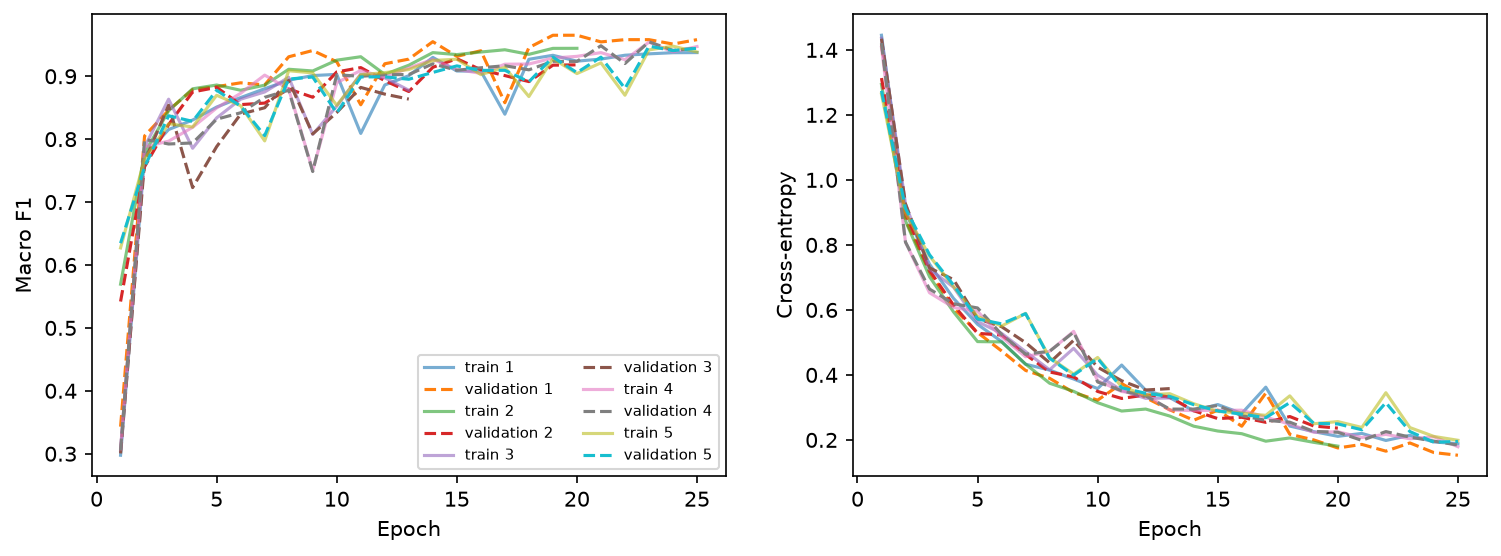

In [8]:
# Recorded sensitivity experiment and learning curves; no further training.
cnn40=show_table('cnn40_folds.csv')
check('Five extended CNN folds present',len(cnn40)==5 and set(cnn40.fold)==set(range(5)))
display(pd.DataFrame([read_json('sensitivity_decision.json')]))
show_table('development_comparison.csv')
show_figure('selected_cnn_learning_curves.png')

## 9. Final refitting and specification freeze

Refit the selected SVM pipeline on all development descriptors. Train a fresh CNN on all development images for the predeclared derived epoch count, estimating its normalisation from development only. There is no final test-guided checkpoint selection. Save both models, verify serialisation using development examples, and hash the files. The freeze record binds model hashes, selection settings, split, folds, subgroup boundaries and perturbations before the test gate opens.

In [9]:
# Inspect the original freeze record and refit history; do not refit or unlock anything.
print('Original specification freeze:',frozen['time_utc'])
print('Recorded final CNN epochs:',frozen['cnn']['refit_epochs'])
check('Original freeze records no pre-freeze test reads',frozen['pre_freeze_test_reads']==0)
show_table('cnn_final_training_history.csv')
print('Saved model hashes already verified. No new model files are created.')

Original specification freeze: 2026-09-27T20:18:00.300038+00:00
Recorded final CNN epochs: 20


,epoch,online_train_loss
0,1,1.356359
1,2,1.007624
2,3,0.801518
3,4,0.674886
4,5,0.592580
5,6,0.518070
6,7,0.454911
7,8,0.421852
8,9,0.398464
9,10,0.376093


Saved model hashes already verified. No new model files are created.


## 10. One primary locked-test evaluation

Load the reserved test images only after the freeze record exists. Both models predict the same ordered images. Cache clean predictions for all later clean diagnostics. Report the four required aggregate metrics, classwise precision/recall/F1/support and confusion matrices. Row-normalised confusion matrices show the distribution of predictions within each true class; counts expose sample size.

The partition is internal to this benchmark, with unknown acquisition-group independence. It cannot demonstrate transfer to other factories, cameras, steel grades or unrepresented defects. No model setting is changed in response to this section.

Recalculated from saved predictions; no new test evaluation.


,model,n,accuracy,precision_macro,recall_macro,f1_macro
0,HOG-SVM,360,0.902778,0.905498,0.902778,0.902302
1,CNN,360,0.955556,0.961108,0.955556,0.955493


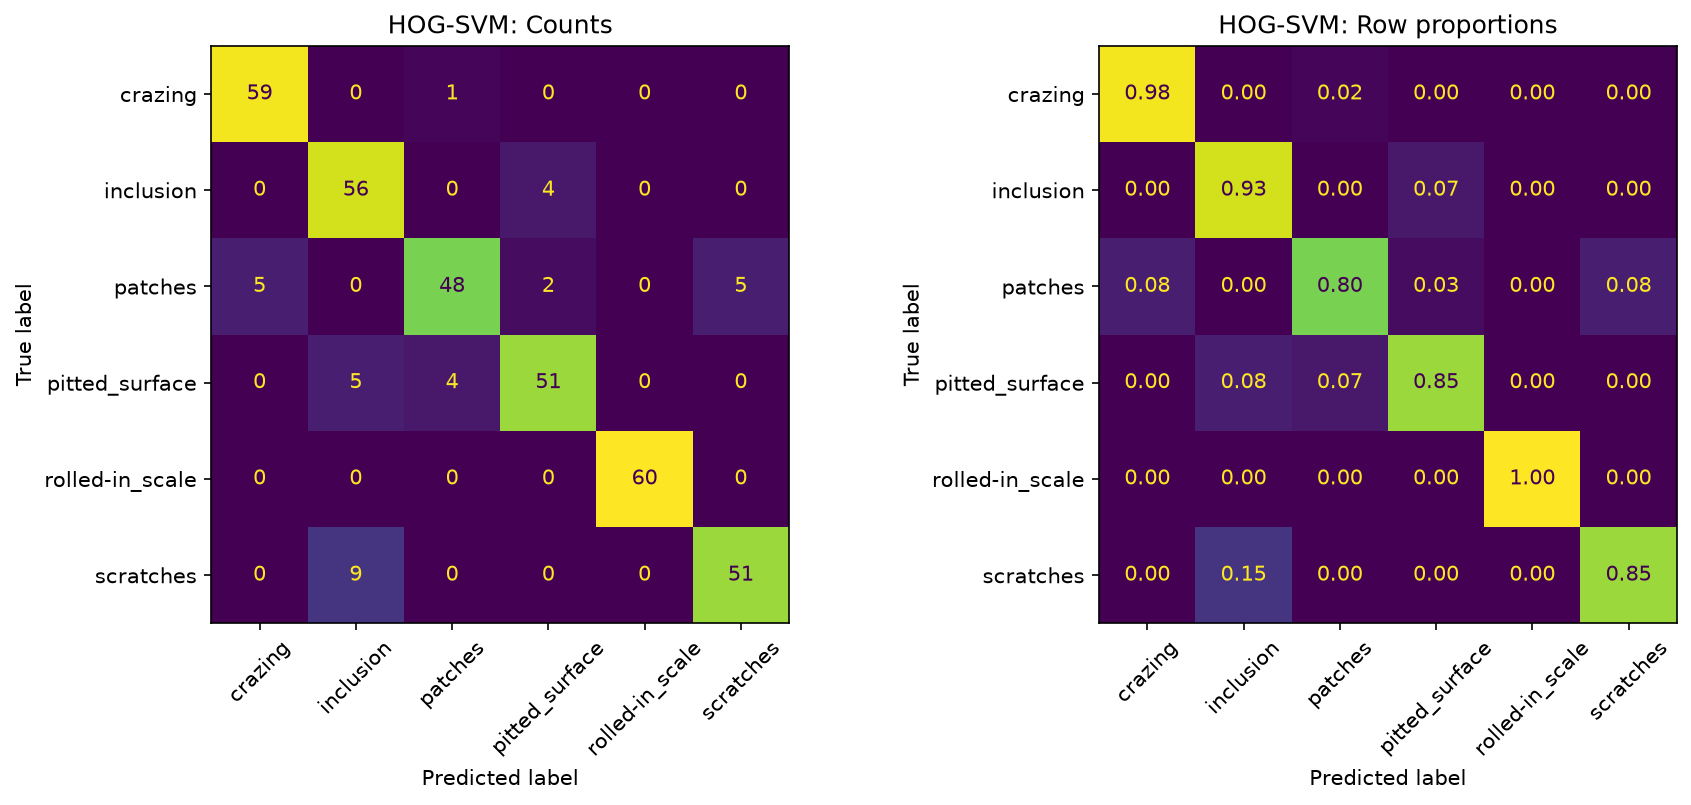

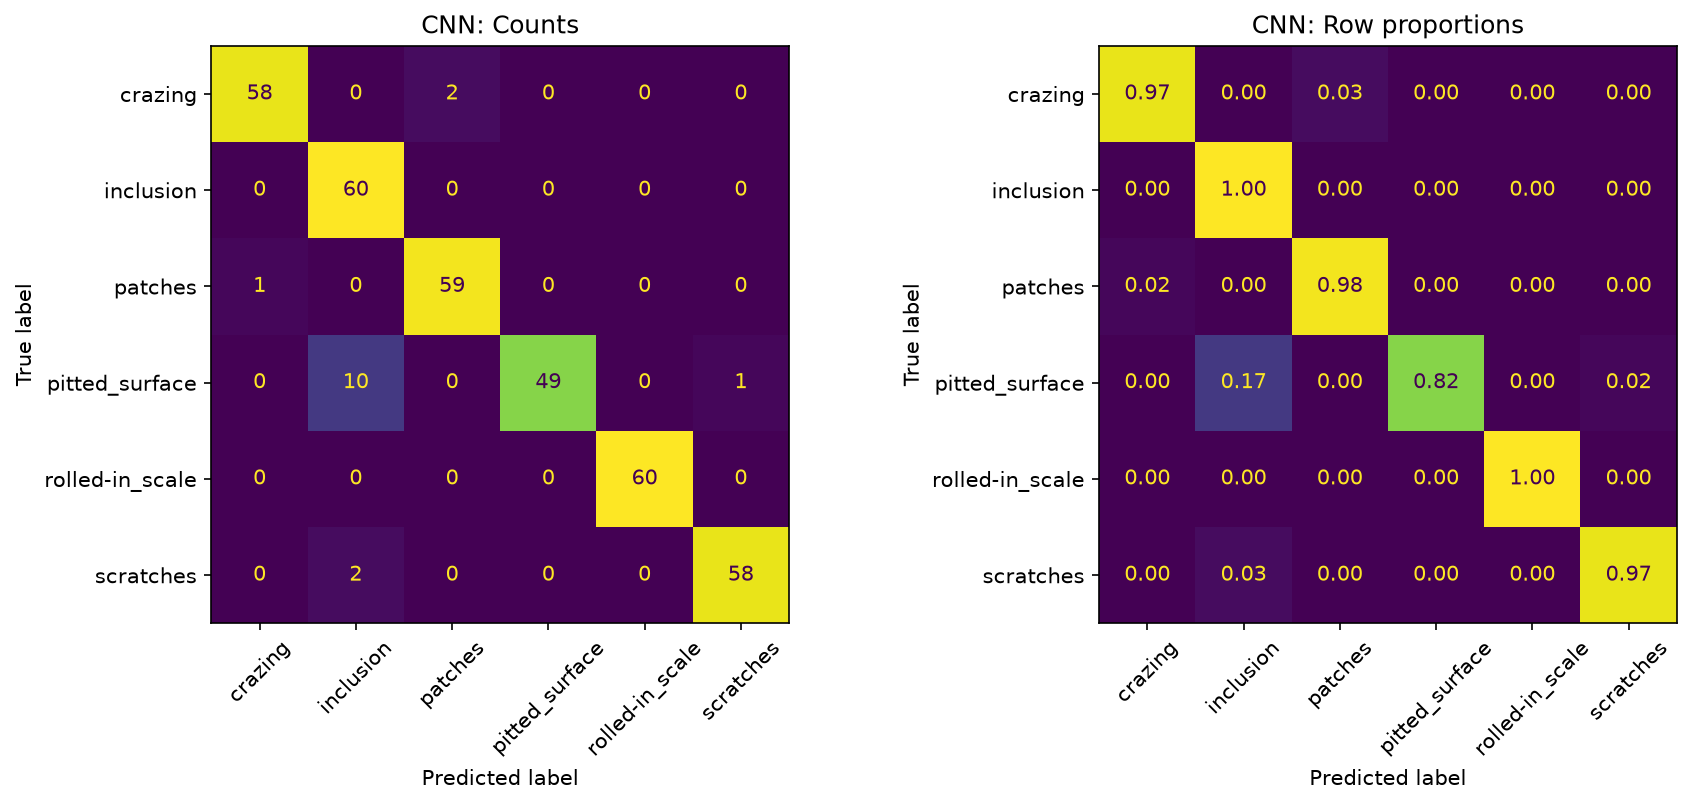

In [10]:
# Recalculate metrics from the original saved prediction labels, not from models/images.
predictions=read_table('test_predictions.csv')
check('Exactly the original 360 ordered test rows',len(predictions)==360 and predictions.path.is_unique and predictions.path.tolist()==test.path.tolist() and predictions.class_name.tolist()==test.class_name.tolist())
check('Recognised ground-truth labels',predictions.class_name.isin(CLASSES).all())
saved=read_table('test_results.csv').set_index('model')
recomputed=[]
for name in ['HOG-SVM','CNN']:
    check(name+' prediction labels valid',predictions[name].isin(CLASSES).all())
    values=metrics(predictions.class_name,predictions[name])
    for metric,value in values.items():
        check(name+' '+metric+' matches saved result',np.isclose(value,saved.loc[name,metric],rtol=0,atol=1e-12))
    expected=next(row for row in result['test_results'] if row['model']==name)
    check(name+' matches completion record',all(np.isclose(v,expected[k],rtol=0,atol=1e-12) for k,v in values.items()))
    cm=confusion_matrix(predictions.class_name,predictions[name],labels=CLASSES)
    saved_cm=read_table(name+'_confusion_counts.csv',index_col=0).loc[CLASSES,CLASSES].to_numpy()
    check(name+' confusion counts reproduced',np.array_equal(cm,saved_cm))
    recomputed.append(dict(model=name,n=360,**values))
print('Recalculated from saved predictions; no new test evaluation.')
display(pd.DataFrame(recomputed).style.format({k:'{:.6f}' for k in ['accuracy','precision_macro','recall_macro','f1_macro']}))
for name in ['HOG-SVM','CNN']:
    show_figure(name+'_confusion.png')

## 11. Disagreement and error diagnostics

Tabulate paired correctness and directed confusions, retaining paths for inspection. Display up to twelve errors or disagreements in deterministic path order; this avoids choosing especially persuasive illustrations. A shared error does not identify its cause, and an agreement is not independent corroboration. These diagnostics are descriptive and cannot justify retuning on the test partition.

In [11]:
# Display original error analysis from the completed experiment.
show_table('paired_correctness.csv')
show_table('directed_errors.csv')

,svm_correct,cnn_correct,disagree,size
0,False,False,False,5
1,False,False,True,1
2,False,True,True,29
3,True,False,True,10
4,True,True,False,315


,model,true_class,predicted_class,count
0,CNN,pitted_surface,inclusion,10
1,HOG-SVM,scratches,inclusion,9
2,HOG-SVM,patches,crazing,5
3,HOG-SVM,patches,scratches,5
4,HOG-SVM,pitted_surface,inclusion,5
5,HOG-SVM,inclusion,pitted_surface,4
6,HOG-SVM,pitted_surface,patches,4
7,CNN,crazing,patches,2
8,CNN,scratches,inclusion,2
9,HOG-SVM,patches,pitted_surface,2


,model,true_class,predicted_class,count
0,CNN,pitted_surface,inclusion,10
1,HOG-SVM,scratches,inclusion,9
2,HOG-SVM,patches,crazing,5
3,HOG-SVM,patches,scratches,5
4,HOG-SVM,pitted_surface,inclusion,5
5,HOG-SVM,inclusion,pitted_surface,4
6,HOG-SVM,pitted_surface,patches,4
7,CNN,crazing,patches,2
8,CNN,scratches,inclusion,2
9,HOG-SVM,patches,pitted_surface,2


## 12. CNN Grad-CAM and HOG representation

Use Captum LayerGradCam on the final convolutional layer, with the predicted class as target and ReLU applied to the attribution [5,6]. Upsample the coarse map for display and normalise each map independently; colour intensity is therefore not comparable across images. Select the first test example of each true class, then up to three errors in path order. Record target, true label and map range, including constant maps.

Grad-CAM describes local sensitivity in this model, not a causal explanation or validated defect boundary. Pooling limits resolution. No localisation ground truth or explanation faithfulness experiment is used here. HOG visualisation shows an input representation, **not SVM attribution**, and must not be read as a class-specific explanation.

In [12]:
# Display already-created explanations. No gradients or predictions are computed.
show_table('gradcam_registry.csv')
if SHOW_LARGE_EXPLANATION_FIGURE:
    show_figure('explanations.png',900)
else:
    print('Original Grad-CAM figure checksum verified. Set SHOW_LARGE_EXPLANATION_FIGURE=True in the first cell to display it.')
print('Grad-CAM is an explanation aid, not proof of causal reliance or operational safety.')

,path,true_class,target_class,cam_min,cam_max,constant_map
0,data/NEU-CLS/train/train/images/crazing_100.jpg,crazing,crazing,0.001049,0.016687,False
1,data/NEU-CLS/train/train/images/inclusion_102.jpg,inclusion,inclusion,0.000000,0.003646,False
2,data/NEU-CLS/train/train/images/patches_10.jpg,patches,patches,0.004107,0.025106,False
3,data/NEU-CLS/train/train/images/pitted_surface...,pitted_surface,inclusion,0.000000,0.004988,False
4,data/NEU-CLS/train/train/images/rolled-in_scal...,rolled-in_scale,rolled-in_scale,0.000000,0.011820,False
5,data/NEU-CLS/train/train/images/scratches_101.jpg,scratches,scratches,0.002796,0.014720,False
6,data/NEU-CLS/train/train/images/crazing_19.jpg,crazing,patches,0.004890,0.018390,False
7,data/NEU-CLS/train/train/images/crazing_294.jpg,crazing,crazing,0.000000,0.016139,False
8,data/NEU-CLS/train/train/images/crazing_77.jpg,crazing,patches,0.004920,0.018457,False


Original Grad-CAM figure checksum verified. Set SHOW_LARGE_EXPLANATION_FIGURE=True in the first cell to display it.
Grad-CAM is an explanation aid, not proof of causal reliance or operational safety.


## 13. Objective image-condition subgroups

Apply development-derived tertile boundaries without recomputing them on test images. Report subgroup size, all six class counts and the required metrics. Macro metrics always use the six-class label vocabulary, setting undefined values to zero; small or absent class supports limit comparisons. Brightness, contrast and sharpness groups overlap across diagnostic dimensions. Differences are associations and may reflect class composition, not independent effects of image quality.

In [13]:
# Original subgroup results, using the recorded development-derived thresholds.
show_table('subgroup_composition.csv')
show_table('subgroup_metrics.csv')

,condition,group,n,crazing,inclusion,patches,pitted_surface,rolled-in_scale,scratches
0,brightness,low,121,10,33,14,11,14,39
1,brightness,middle,118,25,17,11,9,39,17
2,brightness,high,121,25,10,35,40,7,4
3,contrast,low,120,0,51,0,11,36,22
4,contrast,middle,120,29,7,4,29,24,27
5,contrast,high,120,31,2,56,20,0,11
6,sharpness,low,121,0,60,0,20,0,41
7,sharpness,middle,118,0,0,11,40,48,19
8,sharpness,high,121,60,0,49,0,12,0


,condition,group,model,n,accuracy,precision_macro,recall_macro,f1_macro
0,brightness,low,HOG-SVM,121,0.917355,0.930235,0.898490,0.904302
1,brightness,low,CNN,121,0.958678,0.965278,0.932090,0.944293
2,brightness,middle,HOG-SVM,118,0.932203,0.934704,0.901929,0.910126
3,brightness,middle,CNN,118,0.940678,0.951389,0.879085,0.883161
4,brightness,high,HOG-SVM,121,0.859504,0.819181,0.836310,0.811915
5,brightness,high,CNN,121,0.966942,0.932479,0.982738,0.954153
6,contrast,low,HOG-SVM,120,0.933333,0.633658,0.602793,0.614296
7,contrast,low,CNN,120,0.966667,0.649832,0.613636,0.628013
8,contrast,middle,HOG-SVM,120,0.908333,0.833889,0.899380,0.853224
9,contrast,middle,CNN,120,0.933333,0.867521,0.953597,0.891846


,condition,group,model,n,accuracy,precision_macro,recall_macro,f1_macro
0,brightness,low,HOG-SVM,121,0.917355,0.930235,0.898490,0.904302
1,brightness,low,CNN,121,0.958678,0.965278,0.932090,0.944293
2,brightness,middle,HOG-SVM,118,0.932203,0.934704,0.901929,0.910126
3,brightness,middle,CNN,118,0.940678,0.951389,0.879085,0.883161
4,brightness,high,HOG-SVM,121,0.859504,0.819181,0.836310,0.811915
5,brightness,high,CNN,121,0.966942,0.932479,0.982738,0.954153
6,contrast,low,HOG-SVM,120,0.933333,0.633658,0.602793,0.614296
7,contrast,low,CNN,120,0.966667,0.649832,0.613636,0.628013
8,contrast,middle,HOG-SVM,120,0.908333,0.833889,0.899380,0.853224
9,contrast,middle,CNN,120,0.933333,0.867521,0.953597,0.891846


## 14. Controlled mild robustness stress tests

Apply the frozen Gaussian blur, brightness factors, mean-centred contrast reduction and Gaussian noise independently to clean test images [7]. Use the same transformed arrays for both models, fixed noise seed, clipping to [0,1] and uint8 rounding. Report accuracy and macro F1 alongside changes from each model's cached clean score. There is no severity search or retraining.

These are synthetic stress tests, **not proof of real factory distribution-shift performance**. Perturbations are assumed to preserve defect labels at these mild severities, an assumption that needs domain validation. Real shifts can alter material, acquisition, prevalence and labels in ways these operators cannot represent [8].

,condition,model,n,accuracy,f1_macro,delta_accuracy,delta_f1
0,clean,HOG-SVM,360,0.902778,0.902302,0.000000,0.000000
1,clean,CNN,360,0.955556,0.955493,0.000000,0.000000
2,blur,HOG-SVM,360,0.772222,0.765914,-0.130556,-0.136389
3,blur,CNN,360,0.608333,0.554670,-0.347222,-0.400823
4,brightness_low,HOG-SVM,360,0.905556,0.905119,0.002778,0.002817
5,brightness_low,CNN,360,0.936111,0.936887,-0.019444,-0.018606
6,brightness_high,HOG-SVM,360,0.847222,0.847232,-0.055556,-0.055070
7,brightness_high,CNN,360,0.941667,0.940553,-0.013889,-0.014940
8,contrast,HOG-SVM,360,0.905556,0.904840,0.002778,0.002537
9,contrast,CNN,360,0.938889,0.939504,-0.016667,-0.015990


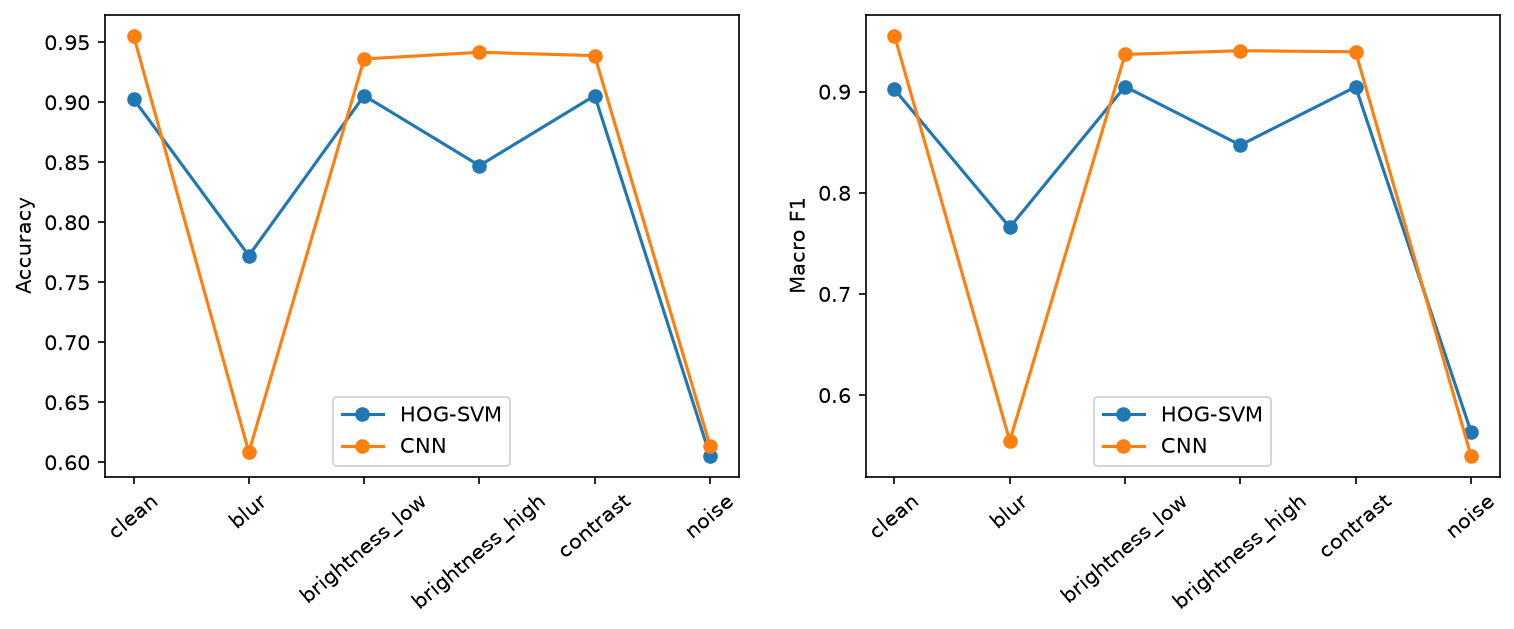

No images were perturbed and no models were run during this verification.


In [14]:
# Recompute robustness scores from saved perturbed-image predictions only.
robust=read_table('robustness.csv')
for condition in ['blur','brightness_low','brightness_high','contrast','noise']:
    stored=read_table('predictions_'+condition+'.csv')
    check(condition+' prediction paths match',stored.path.tolist()==predictions.path.tolist())
    for name in ['HOG-SVM','CNN']:
        check(condition+' '+name+' class indices valid',stored[name].isin(range(6)).all())
        labels=[CLASSES[int(i)] for i in stored[name]]
        values=metrics(predictions.class_name,labels)
        row=robust.loc[robust.condition.eq(condition)&robust.model.eq(name)]
        check(condition+' '+name+' has one saved row',len(row)==1)
        for metric in ['accuracy','f1_macro']:
            check(condition+' '+name+' '+metric+' reproduced',np.isclose(values[metric],row.iloc[0][metric],rtol=0,atol=1e-12))
show_table('robustness.csv')
show_figure('robustness_comparison.png')
print('No images were perturbed and no models were run during this verification.')

## 15. Same-machine efficiency measurements

Report development feature extraction, candidate-search/CV time and final refit time separately. CNN CV timing includes epoch diagnostics and checkpointing, so it is not equivalent to pure optimisation time. Record parameter count, HOG dimension and serialised model file sizes.

For inference, use a fixed subset of development images, warm up each route three times, then take thirty timed single-image measurements. Report median and 95th percentile latency for decoding, preprocessing, classifier-only work and the combined route from file opening to prediction. OS file caching is warm. Measure batch throughput separately over the same development subset; do not infer it from single-image latency. CPU threads are recorded, and results depend on hardware, load and batching. Timing calls do not generate additional primary test scores. SVM inference includes scaling in its classifier pipeline; HOG extraction is a separate preprocessing cost.

In [15]:
# Preserve original timing numbers: show saved measurements rather than re-benchmarking.
show_table('efficiency.csv')
show_table('latency.csv')
print('These are the original recorded timings. Demo runtime is not model training or inference time.')

,model,development_preprocessing_seconds,selection_seconds,refit_seconds,file_bytes,trainable_parameters,hog_dimensions
0,HOG-SVM,27.25847,224.835336,15.386096,43632616,NaN,4356.0
1,CNN,NaN,1460.303181,107.802319,31963,6142.0,NaN


,route,median_ms,p95_ms,repeats
0,shared_decode,2.85205,5.685880,30
1,svm_hog_preprocessing,10.85950,13.731775,30
2,svm_classifier_with_scaling,11.66815,13.171680,30
3,svm_file_to_prediction,29.44940,35.591340,30
4,cnn_normalisation,0.32325,0.571725,30
5,cnn_forward,4.44560,5.664670,30
6,cnn_file_to_prediction,7.09575,8.840090,30


These are the original recorded timings. Demo runtime is not model training or inference time.


## 16. Ethics, limitations and deployment context

**Decision context.** A potential use is assisting a trained inspector in categorising already identified defect crops. Misclassification may misdirect remediation, while an automated acceptance decision could release unsafe material. This benchmark supplies no normal material, defect severity, downstream cost or acceptable-risk threshold. Consequently, neither a high aggregate metric nor a compelling heatmap justifies autonomous acceptance or rejection of steel.

**Evidence boundaries.** Image-level splitting cannot establish coil-, production-line- or factory-level independence without acquisition identifiers. Exact duplicate exclusion leaves near-duplicate risk. A small curated benchmark, one split and one initialisation per fold do not characterise deployment uncertainty. CV selection, epoch selection and the cap check share development evidence. Test subgroups can be small and class-confounded. Earlier familiarity with the benchmark limits claims of novelty and prospective blindness. Independent temporal and factory validation is needed before operational claims [2,8,9].

**Human oversight and accountability.** Retain qualified inspection, define escalation and abstention policies, document decision ownership and give operators a route to contest errors. Validate calibration and rejection thresholds on separate operational validation data before relying on confidence. Monitor class-specific failures and material/camera changes. Collect representative normal surfaces and out-of-scope defects, agree cost-sensitive acceptance criteria with process engineers and assess harmful false accepts separately from unnecessary rejects. Heatmaps cannot replace those controls.

**Data and reproducibility.** Attribute the dataset researchers and Figshare distributor, respect the stated distribution licence, record transformations and retain immutable raw inputs. Production images may expose proprietary processes or employee information even if this benchmark does not: minimise collection, control access and agree retention. Preserve versioned models, preprocessing and audit trails, define rollback and review responsibilities, and assess drift with labelled follow-up samples. Do not repurpose image-condition subgroup results as demographic fairness evidence.

**Resource use.** Bounded CPU training and explicit cost measurements make the computational budget visible, but latency is not energy use or a production service-level guarantee. Deployment assessment requires the actual acquisition pipeline, hardware, batch sizes, workload, maintenance and human review costs. No deployment approval is inferred from this notebook.

## 17. Completion and reproducibility checks

Verify the frozen specification and model files have not changed, all shared folds completed, test ordering is identical, values are finite and pre-freeze raw opens were development-only. Save the access record, checks and a machine-readable result summary in the fresh run directory. Inline outputs remain part of the submitted notebook; external run artefacts are useful for auditing but are not prerequisites for rerunning it.

To reproduce, use a fresh kernel and execute the entire notebook in order. Each full execution creates a new run directory. Do not select whichever repeated run happens to score best. If the raw audit fails, investigate the source discrepancy rather than changing acceptance checks to obtain a preferred result.

In [16]:
# Final read-only verification. Nothing is saved into the experiment directory.
for name,expected in PINNED_SHA256.items():
    check('Unchanged at completion: '+name,sha(RUN/name)==expected)
check('All verification checks passed',all(row['result']=='PASS' for row in checks))
display(pd.DataFrame([
    {'Verification':'Original completed experiment and frozen model hashes','Result':'PASS'},
    {'Verification':'Saved split and five development folds','Result':'PASS'},
    {'Verification':'Clean metrics and confusion counts independently recalculated','Result':'PASS'},
    {'Verification':'Robustness metrics recalculated from saved predictions','Result':'PASS'},
    {'Verification':'All referenced evidence files unchanged','Result':'PASS'}]))
print('SAVED EXPERIMENT VERIFICATION: PASS')
print(f'{len(checks)} checks completed in {perf_counter()-START:.2f} seconds.')
print('No training, model inference, raw-image access, downloads or experiment-file writes.')
print('This verifies the saved evidence; it does not rerun the complete training workflow.')

,Verification,Result
0,Original completed experiment and frozen model...,PASS
1,Saved split and five development folds,PASS
2,Clean metrics and confusion counts independent...,PASS
3,Robustness metrics recalculated from saved pre...,PASS
4,All referenced evidence files unchanged,PASS


SAVED EXPERIMENT VERIFICATION: PASS
184 checks completed in 1.17 seconds.
No training, model inference, raw-image access, downloads or experiment-file writes.
This verifies the saved evidence; it does not rerun the complete training workflow.


## References

1. Cao, W. (2025). *NEU-CLS*, version 1. Figshare. [Dataset DOI](https://doi.org/10.6084/m9.figshare.28903550.v1). [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). This is the distribution used here, not a claim that its packaging is identical to a separately hosted original archive.
2. Song, K. and Yan, Y. (2013). A noise robust method based on completed local binary patterns for hot-rolled steel strip surface defects. *Applied Surface Science*, 285, 858-864. [Original NEU database description and citation](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/list/).
3. Dalal, N. and Triggs, B. (2005). Histograms of oriented gradients for human detection. *IEEE Computer Society Conference on Computer Vision and Pattern Recognition*, 1, 886-893. [Author-hosted paper](https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf). The descriptor is adapted here to steel textures, not used as a pretrained detector.
4. Cortes, C. and Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20, 273-297. [DOI](https://doi.org/10.1007/BF00994018).
5. Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D. and Batra, D. (2017). Grad-CAM: Visual explanations from deep networks via gradient-based localization. *IEEE International Conference on Computer Vision*. [Paper and version history](https://arxiv.org/abs/1610.02391).
6. Captum. *Layer GradCAM API documentation*. [Official documentation](https://captum.ai/api/layer.html#layer-gradcam). The installed implementation version is recorded in the environment table.
7. Hendrycks, D. and Dietterich, T. (2019). Benchmarking neural network robustness to common corruptions and perturbations. *International Conference on Learning Representations*. [Paper](https://arxiv.org/abs/1903.12261). The mild operators here are a project-specific stress protocol, not an ImageNet-C benchmark score.
8. Koh, P. W. et al. (2021). WILDS: A benchmark of in-the-wild distribution shifts. *International Conference on Machine Learning*. [Paper](https://arxiv.org/abs/2012.07421).
9. He, Y., Song, K., Meng, Q. and Yan, Y. (2020). An end-to-end steel surface defect detection approach via fusing multiple hierarchical features. *IEEE Transactions on Instrumentation and Measurement*, 69(4), 1493-1504. [Original NEU research and citation listing](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/list/). Its detection task differs from the crop-level classification studied here.